In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score

In [2]:
benchmark_df = pd.read_csv(r'./uniprot_dataset/benchmark_df.csv')
reproduced_df = pd.read_csv(r'./uniprot_dataset/reproduced_df.csv')

In [3]:
print(len(benchmark_df))
print(len(reproduced_df))

72754
72302


In [4]:
# output: intersection
def get_merge_entries(source, target, source_col, target_col):    
    merge_entries = source.rename(
        columns = dict(zip(source_col, target_col))
    ).merge(
        target, on = target_col, how='left', indicator=True, suffixes=('', '_y')
    )
    
    missing_entries = merge_entries[merge_entries['_merge'] == 'left_only'].drop(columns=['_merge'])
    print(f"Missing (seq_id, mut_name) pairs in target: {len(missing_entries)}")
    #print(missing_entries.head())

    return merge_entries

In [5]:
merge_entries = get_merge_entries(benchmark_df, reproduced_df, ['uniprot_id', 'aa_change'], ['seq_id', 'mut_name'])
benchmark_df = merge_entries[merge_entries['_merge'] == 'both'][['seq_id', 'mut_name', 'ESM1b_score', 'clinvar_label']].rename(
    columns={'seq_id' : 'uniprot_id', 'mut_name' : 'aa_change'}
)
print(len(benchmark_df))
benchmark_df.head()

Missing (seq_id, mut_name) pairs in target: 452
72302


,uniprot_id,aa_change,ESM1b_score,clinvar_label
0,A0AUZ9,N660S,-3.064,NaN
1,A0AV02,R664Q,-7.572,NaN
2,A0AV02,K342R,-5.013,NaN
3,A0AV02,R181C,-10.698,NaN
4,A0AV02,K541R,-2.938,NaN


In [6]:
benchmark_score = benchmark_df['ESM1b_score'].values
reproduced_score_dict = {'ESM1b' : reproduced_df['ESM1b_score'].values,
                         'ESM1v-1' : reproduced_df['ESM1v-1_score'].values,
                         'ESM2' : reproduced_df['ESM2_score'].values,
                         'ProtBERT' : reproduced_df['ProtBERT_score'].values
                        }

RMS of differences: 0.11335131703553794
indices of mutations with diff > 5: {921: {'seq_id': 'O00255', 'mut_name': 'H139R'}, 923: {'seq_id': 'O00255', 'mut_name': 'H139Q'}, 924: {'seq_id': 'O00255', 'mut_name': 'H139D'}, 9590: {'seq_id': 'P01106', 'mut_name': 'P72S'}, 15176: {'seq_id': 'P08519', 'mut_name': 'R2016C'}, 22051: {'seq_id': 'P23109', 'mut_name': 'K320I'}, 35948: {'seq_id': 'Q01433', 'mut_name': 'R324P'}, 40036: {'seq_id': 'Q13507', 'mut_name': 'R762H'}, 48607: {'seq_id': 'Q6ZVW7', 'mut_name': 'C299Y'}, 61739: {'seq_id': 'Q9BRI3', 'mut_name': 'G87R'}, 65245: {'seq_id': 'Q9HBL0', 'mut_name': 'V25I'}, 71095: {'seq_id': 'Q9Y2K3', 'mut_name': 'M1798V'}}
Total = 12


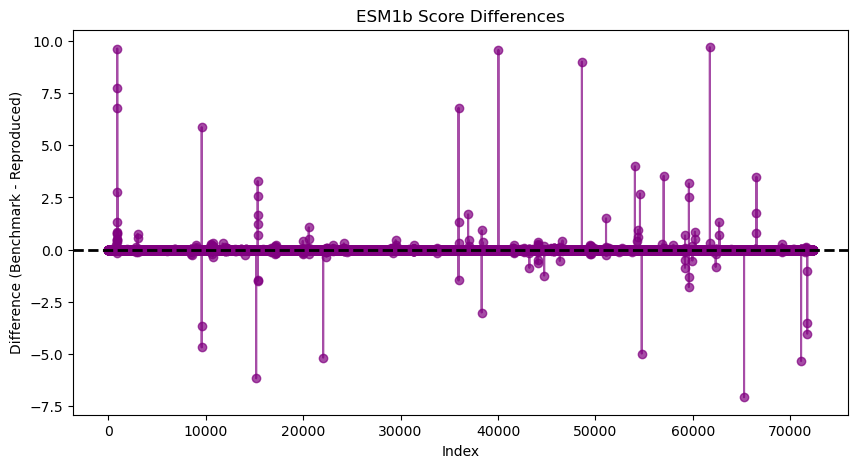

In [7]:
differences = np.array(benchmark_score) - np.array(reproduced_score_dict['ESM1b'])

rms = np.sqrt(np.mean(differences**2))
print(f"RMS of differences: {rms}")

significant_indices = np.where(abs(differences) > 5)[0].tolist()
significant_names = reproduced_df.iloc[significant_indices][['seq_id', 'mut_name']].to_dict(orient='records')
significant_annotations = dict(zip(significant_indices, significant_names))
print(f'indices of mutations with diff > 5: {significant_annotations}')
print(f'Total = {len(significant_annotations)}')

plt.figure(figsize=(10, 5))

plt.plot(differences, marker='o', linestyle='-', color='purple', alpha=0.7)

plt.axhline(0, color='black', linestyle='dashed', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Difference (Benchmark - Reproduced)')
plt.title('ESM1b Score Differences')

plt.savefig(r'./uniprot_dataset/difference_plot.jpg')
plt.show()

In [8]:
benchmark_df_labeled = benchmark_df.dropna(subset=['clinvar_label'])
merge_entries = get_merge_entries(benchmark_df_labeled, reproduced_df, ['uniprot_id', 'aa_change'], ['seq_id', 'mut_name'])

reproduced_df_labeled = merge_entries[merge_entries['_merge'] == 'both'].drop(columns=['ESM1b_score', '_merge']).rename(columns={'ESM1b_score_y' : 'ESM1b_score'})

print(len(benchmark_df_labeled))
print(len(reproduced_df_labeled))

benchmark_score_labeled = -benchmark_df_labeled['ESM1b_score'].values
benchmark_label = benchmark_df_labeled['clinvar_label'].values
reproduced_score_labeled_dict = {'ESM1b' : -reproduced_df_labeled['ESM1b_score'].values,
                                 'ESM1v-1' : -reproduced_df_labeled['ESM1v-1_score'].values,
                                 'ESM2' : -reproduced_df_labeled['ESM2_score'].values,
                                 'ProtBERT' : -reproduced_df_labeled['ProtBERT_score'].values
                                }
reproduced_label = reproduced_df_labeled['clinvar_label'].values

Missing (seq_id, mut_name) pairs in target: 0
53491
53491


In [9]:
benchmark_roc_auc = roc_auc_score(benchmark_label, benchmark_score_labeled)
reproduced_roc_auc = {model_name : roc_auc_score(reproduced_label, model_value) for model_name, model_value in reproduced_score_labeled_dict.items()}

print(f'ROC_AUC for benchmark = {benchmark_roc_auc}')
print(f'ROC_AUC for reproduced = {reproduced_roc_auc}')

ROC_AUC for benchmark = 0.8983798890673916
ROC_AUC for reproduced = {'ESM1b': 0.8984340101221284, 'ESM1v-1': 0.8634864814320388, 'ESM2': 0.8651514941710897, 'ProtBERT': 0.8142922971439381}


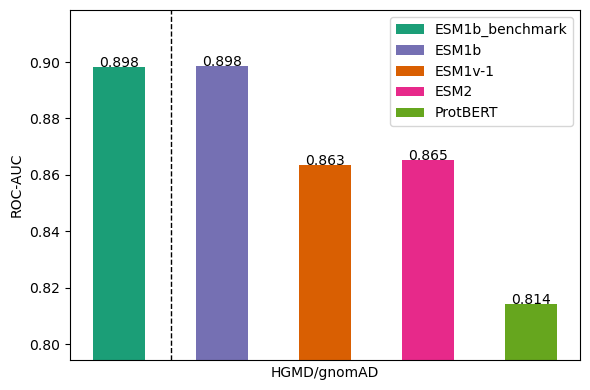

In [10]:
x_labels = ['ESM1b_benchmark'] + list(reproduced_roc_auc.keys())

bar_width = 0.5
colors = dict(zip(x_labels, ['#1b9e77', '#7570b3', '#d95f02', '#e7298a', '#66a61e']))

x = np.arange(len(x_labels))
y = [benchmark_roc_auc] + list(reproduced_roc_auc.values()) 

fig, ax = plt.subplots(figsize=(6, 4))

for x_val, y_val, x_label, curr_color in zip(x, y, x_labels, colors.values()):
    ax.bar(x_val, y_val, width = bar_width, label = x_label, color = curr_color)
    ax.text(x_val, y_val, f"{y_val:.3f}", ha='center', fontsize=10)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1)

ax.set_xticks([])
ax.set_xlabel('HGMD/gnomAD')
ax.set_ylabel("ROC-AUC")
ax.set_ylim(min(list(reproduced_roc_auc.values())) - 0.02, max(list(reproduced_roc_auc.values())) + 0.02)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(r'./uniprot_dataset/roc_auc_score_bar.jpg')
plt.show()